In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
auto_mpg = pd.read_csv("/content/drive/MyDrive/MSC_MU/MSC_SEM_2/ML_ALL_PROGRAM_DS_SEM_2/11_18_Feb/auto-mpg.csv")

In [4]:
auto1=auto_mpg.drop('car name', axis=1)

print(auto1.isnull().sum())


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64


In [5]:
auto1 = auto1.replace('?', np.nan)


In [6]:
print('\n print how many null values are there in each column')
print(auto1.isnull().sum())


 print how many null values are there in each column
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
dtype: int64


In [7]:
auto1['horsepower']=auto1['horsepower'].astype(float)
print('\n datatypes after conversion of horsepower to float')
print(auto1.dtypes)
print(auto1['horsepower'].describe())


 datatypes after conversion of horsepower to float
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object
count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64


In [8]:
print('\n print mean of each column')
print(auto1.mean())



 print mean of each column
mpg               23.514573
cylinders          5.454774
displacement     193.425879
horsepower       104.469388
weight          2970.424623
acceleration      15.568090
model year        76.010050
origin             1.572864
dtype: float64


In [9]:
print('\n after fill null value with mean of the column')
auto2=auto1.fillna(auto1.mean())



 after fill null value with mean of the column


In [10]:
X = auto2.drop(['mpg'], axis=1)
y = auto2['mpg']

# Split the data into training and testing sets


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Initialize the Random Forest regressor


In [12]:
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=42)



# Train the Random Forest regressor


In [13]:
rf_regressor.fit(X_train, y_train)



RandomForestRegressor(n_estimators=50, random_state=42)

In [14]:
y_pred = rf_regressor.predict(X_test)

# Calculate the Mean Squared Error (MSE) and R^2 score


In [15]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Squared Error: 4.447397200000003
R^2 Score: 0.917283032132844


#K MEANS

In [16]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [17]:
data = load_breast_cancer()
X = data.data
y = data.target

# Standardize features


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans Clustering


In [19]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

# we adjust labels to match the true labels


In [20]:
adjusted_labels = np.where(labels == labels[0], y[0], 1 - y[0])


# Optional: Visualize using PCA


In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

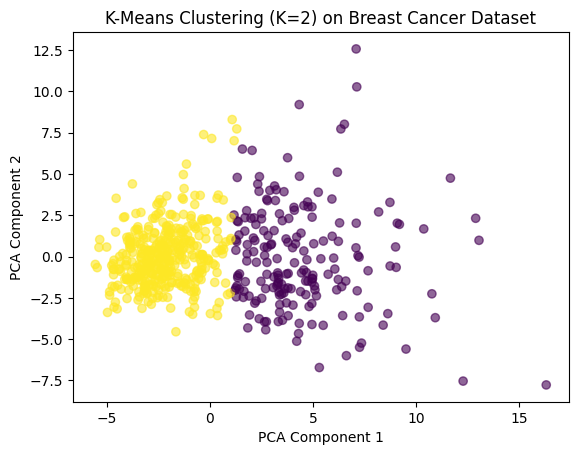

In [23]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=adjusted_labels, cmap='viridis', alpha=0.6)
plt.title("K-Means Clustering (K=2) on Breast Cancer Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()